# Ejercicio 12: Multimodal Embeddings

## *Nombre:* Freddy Jiménez
## *Fecha:* 13/07/2026
## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

####  Instalación de dependencias

In [1]:
# Instalar dependencias (solo la primera vez que ejecutes)
!pip install torch torchvision matplotlib scikit-learn pillow ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ---------------------------------------- 0.0/44.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/44.8 kB ? eta -:--:--
   ------------------ --------------------- 20.5/44.8 kB 330.3 kB/s eta 0:00:01
   --------------------------- ------------ 30.7/44.8 kB 330.3 kB/s eta 0:00:01
   ---------------------------------------- 44.8/44.8 kB 317.3 kB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\FREDDY\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  Cloning https://github.com/openai/CLIP.git to c:\users\freddy\appdata\local\temp\pip-req-build-w50epxtx
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369632 sha256=9d0a34ba7769ffc855dd8ba1f02ea1486214f303b1f073b22ad5e3d338d2aeb9
  Stored in directory: C:\Users\FREDDY\AppData\Local\Temp\pip-ephem-wheel-cache-m1brhdfh\wheels\3f\7c\a4\9b490845988bf7a4db33674d52f709f088f64392063872eb9a
Successfully built clip


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\FREDDY\AppData\Local\Temp\pip-req-build-w50epxtx'

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\FREDDY\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


#### Importar librerías

En esta sección se importan las librerías necesarias para el desarrollo del ejercicio de Multimodal Embeddings. Se utilizan herramientas para el manejo de datos, procesamiento de imágenes, reducción de dimensionalidad y cálculo de similitud entre embeddings.

* os: Permite interactuar con el sistema operativo y gestionar archivos o directorios.
* torch: Biblioteca principal de PyTorch utilizada para el desarrollo de modelos de aprendizaje profundo y el manejo de tensores.
* clip: Implementación del modelo CLIP (Contrastive Language-Image Pretraining), utilizado para generar embeddings tanto de imágenes como de texto en un mismo espacio vectorial.
* numpy: Facilita las operaciones matemáticas y el manejo eficiente de arreglos numéricos.
* matplotlib.pyplot: Se utiliza para la visualización de gráficos y resultados obtenidos durante el análisis.
* PCA (Principal Component Analysis): Método de reducción de dimensionalidad que permite representar los embeddings en un espacio de menor dimensión para su visualización.
* cosine_similarity: Función utilizada para medir la similitud entre vectores de embeddings mediante la similitud del coseno.
* CIFAR10: Conjunto de datos de imágenes ampliamente utilizado en tareas de clasificación y evaluación de modelos de visión por computadora.

Posteriormente, se configura el dispositivo de ejecución del modelo. El código verifica si existe una GPU compatible con CUDA disponible; en caso contrario, se utilizará la CPU. Esto permite aprovechar la aceleración por hardware para reducir el tiempo de procesamiento de los embeddings.

In [2]:
import os
import torch
import clip
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from torchvision.datasets import CIFAR10

# Configurar dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


#### Cargar modelo CLIP

En esta sección se carga el modelo preentrenado CLIP ViT-B/32, el cual permite generar embeddings de imágenes y texto en un mismo espacio vectorial. Además, se obtiene la dimensión del espacio común de representación, que en este caso es de 512 dimensiones.

In [3]:
print("Cargando modelo CLIP (ViT-B/32)...")
model, preprocess = clip.load("ViT-B/32", device=device)
embed_dim = model.visual.output_dim  # 512
print(f"Dimensión del espacio común: {embed_dim}")

Cargando modelo CLIP (ViT-B/32)...


100%|███████████████████████████████████████| 338M/338M [00:07<00:00, 50.3MiB/s]


Dimensión del espacio común: 512


#### Preparar datos (CIFAR-10)

En esta sección se descarga el conjunto de datos CIFAR-10 y se selecciona una imagen representativa de cada una de las diez clases disponibles. Además, se generan descripciones textuales para cada imagen y se visualizan las imágenes seleccionadas para su posterior procesamiento y generación de embeddings.

Descargando CIFAR-10...


100%|██████████| 170M/170M [1:11:36<00:00, 39.7kB/s] 


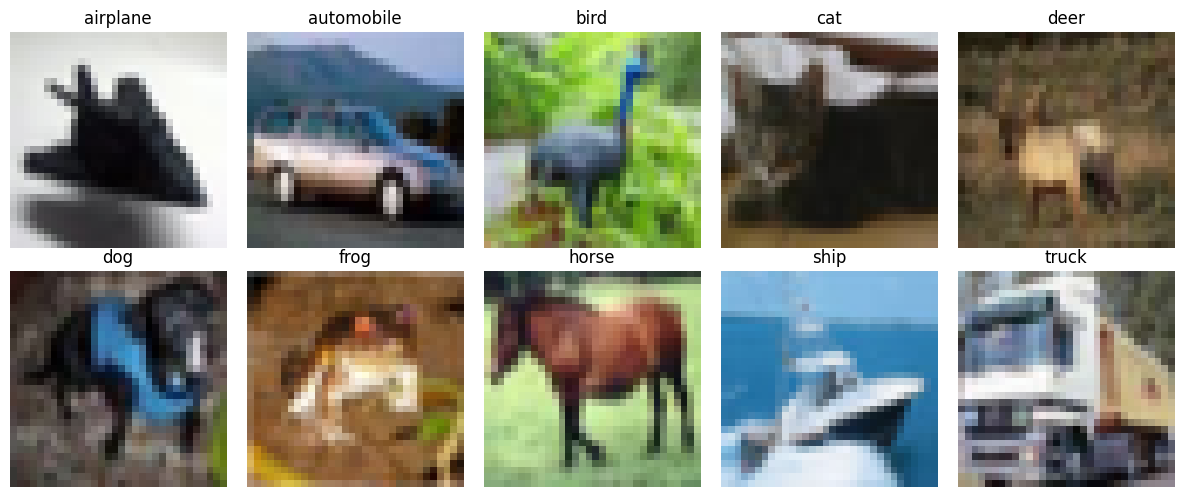

In [4]:
print("Descargando CIFAR-10...")
cifar = CIFAR10(root="./data", train=True, download=True)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# Seleccionar una imagen por clase
selected_images = []
selected_classes = []
for cls in range(10):
    idx = cifar.targets.index(cls)  # primera aparición de la clase
    img, _ = cifar[idx]
    selected_images.append(img)
    selected_classes.append(class_names[cls])

# Textos descriptivos
texts = [f"a photo of a {cls}" for cls in selected_classes]

# Mostrar imágenes elegidas
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(selected_images[i])
    ax.set_title(selected_classes[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

#### Obtener embeddings con CLIP

En esta sección se preprocessan las imágenes y los textos para generar sus respectivos embeddings utilizando el modelo CLIP. Posteriormente, los vectores se normalizan y se convierten a formato NumPy para facilitar su análisis. Finalmente, se verifica que tanto los embeddings de imágenes como los de texto compartan el mismo espacio vectorial de 512 dimensiones.

In [5]:
print("Calculando embeddings...")
# Preprocesar imágenes
image_tensors = torch.stack([preprocess(img) for img in selected_images]).to(device)
# Tokenizar textos
text_tokens = clip.tokenize(texts).to(device)

with torch.no_grad():
    image_embeds = model.encode_image(image_tensors)
    text_embeds = model.encode_text(text_tokens)

# Normalizar
image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

# Convertir a numpy
image_embeds_np = image_embeds.cpu().numpy()
text_embeds_np = text_embeds.cpu().numpy()

print(f"Embeddings de imágenes: {image_embeds_np.shape}")
print(f"Embeddings de textos:   {text_embeds_np.shape}")
print(f"Ambos tienen dimensión {embed_dim}, confirmado.")

Calculando embeddings...
Embeddings de imágenes: (10, 512)
Embeddings de textos:   (10, 512)
Ambos tienen dimensión 512, confirmado.


#### Proyección PCA y visualización

En esta sección se aplica el algoritmo PCA (Análisis de Componentes Principales) para reducir la dimensionalidad de los embeddings a dos dimensiones, permitiendo su visualización gráfica. Posteriormente, se representan los embeddings de imágenes y textos en un plano 2D para analizar la relación y cercanía entre ambas modalidades dentro del espacio vectorial generado por CLIP.

Proyectando a 2D con PCA...


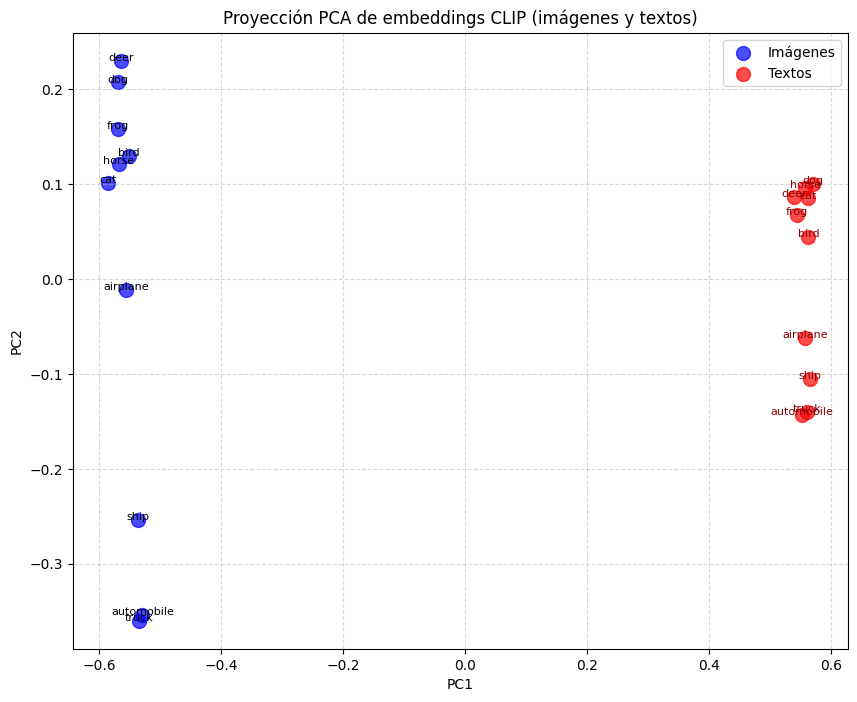

Varianza explicada PC1: 0.64
Varianza explicada PC2: 0.06


In [6]:
print("Proyectando a 2D con PCA...")
all_embeds = np.vstack([image_embeds_np, text_embeds_np])
pca = PCA(n_components=2)
coords = pca.fit_transform(all_embeds)

img_coords = coords[:10]
txt_coords = coords[10:]

plt.figure(figsize=(10, 8))
plt.scatter(img_coords[:, 0], img_coords[:, 1], color='blue', 
            label='Imágenes', s=100, alpha=0.7)
plt.scatter(txt_coords[:, 0], txt_coords[:, 1], color='red', 
            label='Textos', s=100, alpha=0.7)

for i, (x, y) in enumerate(img_coords):
    plt.annotate(selected_classes[i], (x, y), fontsize=8, ha='center')
for i, (x, y) in enumerate(txt_coords):
    plt.annotate(selected_classes[i], (x, y), fontsize=8, 
                 ha='center', color='darkred')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Proyección PCA de embeddings CLIP (imágenes y textos)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Varianza explicada PC1: {pca.explained_variance_ratio_[0]:.2f}")
print(f"Varianza explicada PC2: {pca.explained_variance_ratio_[1]:.2f}")

#### Matriz de similitud coseno

En esta sección se calcula la similitud coseno entre los embeddings de texto y de imágenes para medir qué tan relacionadas están ambas representaciones. Además, se genera una matriz de similitud para visualizar los resultados y se evalúa el desempeño del modelo verificando cuántos textos son asociados correctamente con su imagen correspondiente.

Calculando matriz de similitud...


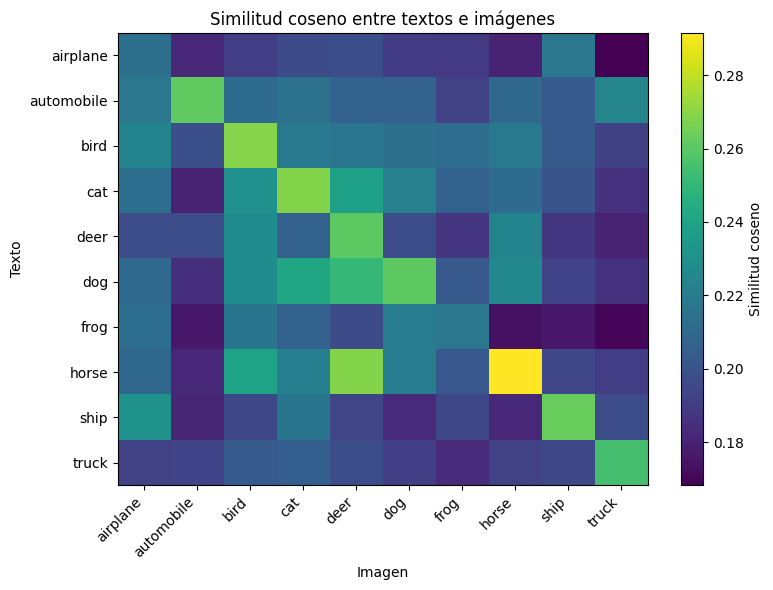

Texto 'a photo of a airplane' → imagen: ship (esperaba airplane)
Texto 'a photo of a automobile' → imagen correcta: automobile
Texto 'a photo of a bird' → imagen correcta: bird
Texto 'a photo of a cat' → imagen correcta: cat
Texto 'a photo of a deer' → imagen correcta: deer
Texto 'a photo of a dog' → imagen correcta: dog
Texto 'a photo of a frog' → imagen: dog (esperaba frog)
Texto 'a photo of a horse' → imagen correcta: horse
Texto 'a photo of a ship' → imagen correcta: ship
Texto 'a photo of a truck' → imagen correcta: truck

Precisión en el batch: 8/10 = 80.0%


In [7]:
print("Calculando matriz de similitud...")
sim_matrix = cosine_similarity(text_embeds_np, image_embeds_np)

plt.figure(figsize=(8, 6))
plt.imshow(sim_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Similitud coseno')
plt.xticks(ticks=np.arange(10), labels=selected_classes, rotation=45, ha='right')
plt.yticks(ticks=np.arange(10), labels=selected_classes)
plt.xlabel('Imagen')
plt.ylabel('Texto')
plt.title('Similitud coseno entre textos e imágenes')
plt.tight_layout()
plt.show()

# Verificar aciertos
correctos = 0
for i in range(10):
    max_idx = np.argmax(sim_matrix[i])
    if max_idx == i:
        correctos += 1
        print(f"Texto '{texts[i]}' → imagen correcta: {selected_classes[i]}")
    else:
        print(f"Texto '{texts[i]}' → imagen: {selected_classes[max_idx]} (esperaba {selected_classes[i]})")
print(f"\nPrecisión en el batch: {correctos}/10 = {correctos/10*100:.1f}%")

#### Búsqueda texto → imagen

En esta sección se realiza una búsqueda texto → imagen utilizando el modelo CLIP. Se genera el embedding de una consulta textual y se calcula su similitud con los embeddings de las imágenes mediante la similitud coseno. Finalmente, se identifica y muestra la imagen más relacionada con la descripción ingresada.


BÚSQUEDA TEXTO → IMAGEN
Consulta: 'a photo of a dog'
Imagen más similar: dog (sim=0.261)


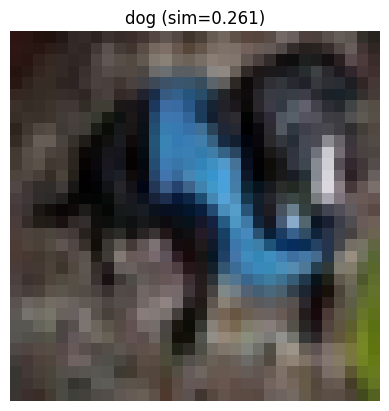

In [8]:
print("\n" + "="*50)
print("BÚSQUEDA TEXTO → IMAGEN")
print("="*50)

query_text = "a photo of a dog"
with torch.no_grad():
    query_embed = model.encode_text(clip.tokenize([query_text]).to(device))
    query_embed = query_embed / query_embed.norm(dim=-1, keepdim=True)

sims = cosine_similarity(query_embed.cpu().numpy(), image_embeds_np).flatten()
best_idx = np.argmax(sims)

print(f"Consulta: '{query_text}'")
print(f"Imagen más similar: {selected_classes[best_idx]} (sim={sims[best_idx]:.3f})")
plt.imshow(selected_images[best_idx])
plt.title(f"{selected_classes[best_idx]} (sim={sims[best_idx]:.3f})")
plt.axis('off')
plt.show()

#### Búsqueda imagen → texto

En esta sección se realiza una búsqueda imagen → texto utilizando los embeddings generados por CLIP. Se selecciona una imagen de consulta y se calcula su similitud con los embeddings de los textos mediante la similitud coseno, identificando la descripción textual más relacionada con la imagen seleccionada.


BÚSQUEDA IMAGEN → TEXTO
Imagen consultada: cat
Texto más similar: 'a photo of a cat' (sim=0.269)


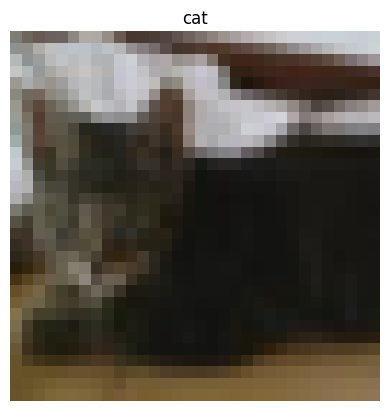

In [9]:
print("\n" + "="*50)
print("BÚSQUEDA IMAGEN → TEXTO")
print("="*50)

img_idx = 3  # gato
query_img_embed = image_embeds_np[img_idx:img_idx+1]
sims = cosine_similarity(query_img_embed, text_embeds_np).flatten()
best_txt_idx = np.argmax(sims)

print(f"Imagen consultada: {selected_classes[img_idx]}")
print(f"Texto más similar: '{texts[best_txt_idx]}' (sim={sims[best_txt_idx]:.3f})")
plt.imshow(selected_images[img_idx])
plt.title(selected_classes[img_idx])
plt.axis('off')
plt.show()